# 📊 Telco Customer Churn (2025) Exploratory Data Analysis (EDA) & Cleaned Pipeline Guide

This Jupyter Notebook analyzes the **Telco Customer Churn 2025** dataset after removing confirmed Data Leakage features.
**Core Goal**: Perform rigorous exploratory data analysis on the 30 remaining features (`df`) after dropping `Churn Label`, `Churn Score`, and `Churn Reason`.

In [27]:
# ============================================================
# 0. Environment Setup & Library Imports
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import warnings

sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
warnings.filterwarnings('ignore')

print('✅ EDA environment setup completed.')

✅ EDA environment setup completed.


In [28]:
# ============================================================
# 1-1. Data Loading
# ============================================================
import os

def get_data_path():
    target = 'Telco-Customer-Churn2025.csv'
    candidates = [
        os.path.join('..', 'data', target),
        os.path.join('data', target),
        target
    ]
    for c in candidates:
        if os.path.exists(c):
            return c
    curr = os.path.abspath(os.getcwd())
    while True:
        c1 = os.path.join(curr, 'data', target)
        if os.path.exists(c1):
            return c1
        c2 = os.path.join(curr, target)
        if os.path.exists(c2):
            return c2
        parent = os.path.dirname(curr)
        if parent == curr:
            break
        curr = parent
    return '../data/Telco-Customer-Churn2025.csv'

data_path = get_data_path()
df_raw = pd.read_csv(data_path)

print(f'📊 Raw Dataset Shape: {df_raw.shape}')
print(f'📂 Loaded File Path: {data_path}')

📊 Raw Dataset Shape: (7043, 33)
📂 Loaded File Path: ../data/Telco-Customer-Churn2025.csv


In [29]:
# ============================================================
# 1-3. 불필요한 피처 제거 (Data Leakage & Target Duplicate)
# ============================================================

drop_cols = [
    'Churn Label',     # 타겟과 중복 (Yes/No → Churn Value로 대체)
    'Churn Score',     # ⚠️ 사후 데이터 / 내부 예측 스코어 (Data Leakage)
    'Churn Reason',    # ⚠️ 사후 발생 데이터 (Data Leakage)
]

existing_drop_cols = [c for c in drop_cols if c in df_raw.columns]
df = df_raw.drop(columns=existing_drop_cols).copy()

print(f'🗑️ 제거된 컬럼 ({len(existing_drop_cols)}개): {existing_drop_cols}')
print(f'✅ 전처리 후 Shape: {df.shape}')
print(f'📋 남은 컬럼 ({len(df.columns)}개): {list(df.columns)}')

🗑️ 제거된 컬럼 (3개): ['Churn Label', 'Churn Score', 'Churn Reason']
✅ 전처리 후 Shape: (7043, 30)
📋 남은 컬럼 (30개): ['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value', 'CLTV']


# ============================================================
# 1-4. 외부 데이터 결합 (Data Enrichment) & Zip Code 전처리
# ============================================================

미국 캘리포니아 지역의 고차원(High-Cardinality) `Zip Code` 변수의 차원의 저주를 방지하고 경제적 환경을 모델에 반영하기 위해:
1. `Zip3` (앞 3자리 광역 지역군) 파생 변수를 생성합니다.
2. `uszipcode` 라이브러리를 통해 각 우편번호의 평균 가구 소득(`Area_Avg_Income`) 및 인구 밀도(`Area_Pop_Density`) 오픈 데이터를 Left Join으로 결합합니다.
3. 매핑 실패 건은 `Zip3` 그룹 평균 ➔ 전체 캘리포니아 중앙값(Median) 순으로 계층적 대체(Fallback Imputation)를 수행합니다.
4. 처리 완료 후 원본 `Zip Code` 컬럼을 삭제합니다.

In [30]:
# ------------------------------------------------------------------------------
# Phase 0. 필요 라이브러리 설치 및 임포트
# ------------------------------------------------------------------------------
# Jupyter 커널 환경 및 macOS PEP 668(externally-managed-environment) 대응 패키지 설치
%pip install -q --break-system-packages "uszipcode" "sqlalchemy<2.0" "sqlalchemy-mate<2.0"

import pandas as pd
import numpy as np
from uszipcode import SearchEngine
import warnings
warnings.filterwarnings('ignore')

# ------------------------------------------------------------------------------
# Phase 1. Zip Code 정규화 및 광역 지역군 (Zip3) 파생 변수 생성
# ------------------------------------------------------------------------------
df['Zip Code_Clean'] = df['Zip Code'].astype(str).str.split('.').str[0].str.zfill(5)
df['Zip3'] = df['Zip Code_Clean'].str[:3]

# ------------------------------------------------------------------------------
# Phase 2. 외부 Open Data (uszipcode) 획득 및 Left Join (Data Enrichment)
# ------------------------------------------------------------------------------
unique_zips = df['Zip Code_Clean'].unique()
search = SearchEngine()

enrichment_data = []
for z in unique_zips:
    res = search.by_zipcode(z)
    if res and res.zipcode:
        income = res.median_household_income
        density = res.population_density
    else:
        income = np.nan
        density = np.nan
        
    enrichment_data.append({
        'Zip Code_Clean': z,
        'Area_Avg_Income': income,
        'Area_Pop_Density': density
    })

df_enrichment = pd.DataFrame(enrichment_data)
df = df.merge(df_enrichment, on='Zip Code_Clean', how='left')

# ------------------------------------------------------------------------------
# Phase 3. 매핑 실패 및 결측치 처리 (Hierarchical Fallback Logic)
# ------------------------------------------------------------------------------
df['Area_Avg_Income'] = df['Area_Avg_Income'].fillna(
    df.groupby('Zip3')['Area_Avg_Income'].transform('mean')
)
df['Area_Pop_Density'] = df['Area_Pop_Density'].fillna(
    df.groupby('Zip3')['Area_Pop_Density'].transform('mean')
)

ca_income_median = df['Area_Avg_Income'].median()
ca_density_median = df['Area_Pop_Density'].median()

df['Area_Avg_Income'] = df['Area_Avg_Income'].fillna(ca_income_median)
df['Area_Pop_Density'] = df['Area_Pop_Density'].fillna(ca_density_median)

# ------------------------------------------------------------------------------
# Phase 4. 품질 검증 및 원본 변수 정리 (Drop)
# ------------------------------------------------------------------------------
assert df['Area_Avg_Income'].isnull().sum() == 0, "Error: Area_Avg_Income에 결측치가 존재합니다."
assert df['Area_Pop_Density'].isnull().sum() == 0, "Error: Area_Pop_Density에 결측치가 존재합니다."

cols_to_drop = ['Zip Code', 'Zip Code_Clean']
df.drop(columns=[col for col in cols_to_drop if col in df.columns], inplace=True)

print(f"✅ Data Enrichment & Zip Code 전처리 완료! (현재 컬럼 수: {len(df.columns)}개)")
print(f"📋 추가된 파생 변수: `Zip3`, `Area_Avg_Income`, `Area_Pop_Density` (원본 `Zip Code` 삭제 완료)")

Note: you may need to restart the kernel to use updated packages.
Download ~/.uszipcode/simple_db.sqlite from https://github.com/MacHu-GWU/uszipcode-project/releases/download/1.0.1.db/simple_db.sqlite ...
  1.00 MB downloaded ...
  2.00 MB downloaded ...
  3.00 MB downloaded ...
  4.00 MB downloaded ...
  5.00 MB downloaded ...
  6.00 MB downloaded ...
  7.00 MB downloaded ...
  8.00 MB downloaded ...
  9.00 MB downloaded ...
  10.00 MB downloaded ...
  11.00 MB downloaded ...
  Complete!
✅ Data Enrichment & Zip Code 전처리 완료! (현재 컬럼 수: 32개)
📋 추가된 파생 변수: `Zip3`, `Area_Avg_Income`, `Area_Pop_Density` (원본 `Zip Code` 삭제 완료)


## 1. 정제된 데이터(`df`) 기본 구조 및 결측치/고유값 시각화 분석

Data Leakage 피처 3개가 제거된 정제된 데이터셋(`df`, 총 30개 피처)의 **데이터 완성도(Completeness Rate %)** 및 **고유값 개수(Unique Value Counts)**를 시각화합니다.

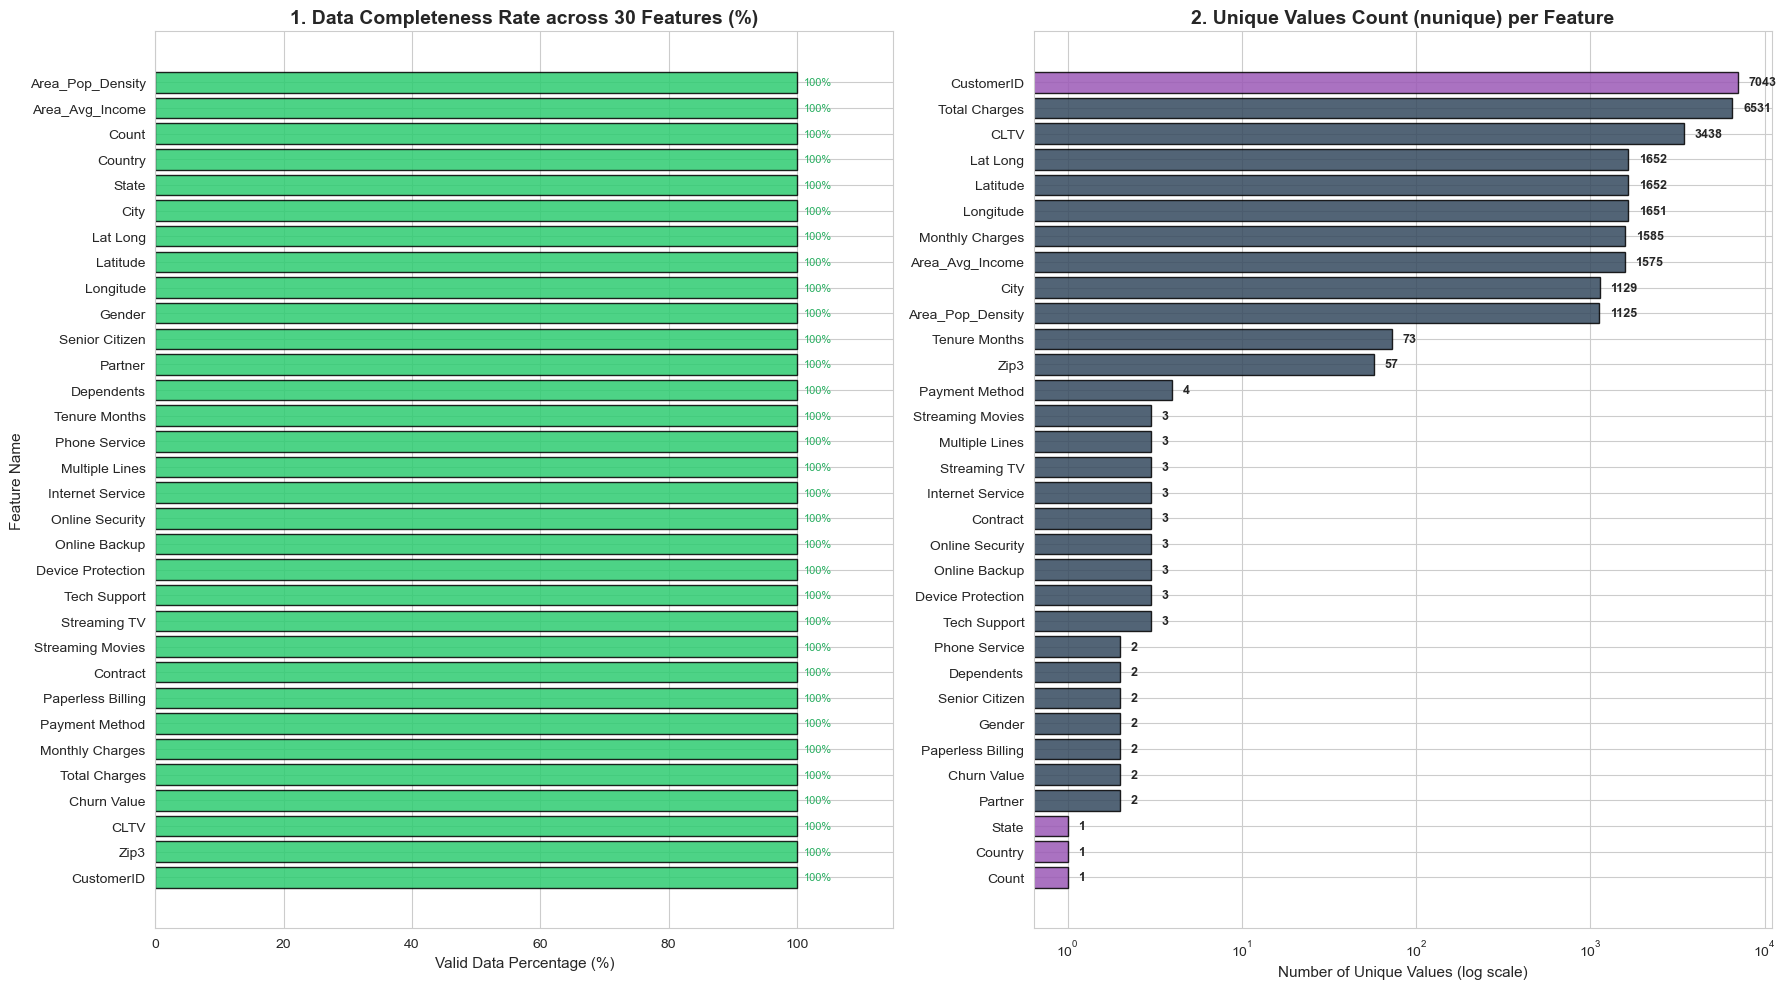

=== 📋 정제된 피처(30개) 요약표 ===
               Column    Dtype  Missing_Count  Missing_Pct  Nunique
0          CustomerID      str              0          0.0     7043
1               Count    int64              0          0.0        1
2             Country      str              0          0.0        1
3               State      str              0          0.0        1
4                City      str              0          0.0     1129
5            Lat Long      str              0          0.0     1652
6            Latitude  float64              0          0.0     1652
7           Longitude  float64              0          0.0     1651
8              Gender      str              0          0.0        2
9      Senior Citizen      str              0          0.0        2
10            Partner      str              0          0.0        2
11         Dependents      str              0          0.0        2
12      Tenure Months    int64              0          0.0       73
13      Phone Service 

In [31]:
# ============================================================
# 1-2. 정제된 데이터(df) 완성도 및 고유값 분석
# ============================================================

summary_df = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Pct': (df.isnull().sum() / len(df)) * 100,
    'Complete_Pct': ((len(df) - df.isnull().sum()) / len(df)) * 100,
    'Nunique': df.nunique(),
    'Dtype': df.dtypes.astype(str)
}).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# (1) Feature Data Completeness Rate (%)
summary_sorted = summary_df.sort_values(by='Complete_Pct', ascending=True)
bars1 = axes[0].barh(summary_sorted['Column'], summary_sorted['Complete_Pct'], color='#2ecc71', edgecolor='black', alpha=0.85)
axes[0].set_title('1. Data Completeness Rate across 30 Features (%)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Valid Data Percentage (%)', fontsize=11)
axes[0].set_ylabel('Feature Name', fontsize=11)
axes[0].set_xlim(0, 115)

for bar in bars1:
    axes[0].text(101, bar.get_y() + bar.get_height()/2, '100%', va='center', fontsize=8, color='#27ae60')

# (2) Unique Values Count (nunique) per Feature
summary_nun_sorted = summary_df.sort_values(by='Nunique', ascending=True)
colors2 = ['#9b59b6' if nun in [1, len(df)] else '#34495e' for nun in summary_nun_sorted['Nunique']]
bars2 = axes[1].barh(summary_nun_sorted['Column'], summary_nun_sorted['Nunique'], color=colors2, edgecolor='black', alpha=0.85)
axes[1].set_title('2. Unique Values Count (nunique) per Feature', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Unique Values (log scale)', fontsize=11)
axes[1].set_xscale('log')

for bar in bars2:
    width = bar.get_width()
    axes[1].text(width * 1.15, bar.get_y() + bar.get_height()/2, f'{int(width)}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print('=== 📋 정제된 피처(30개) 요약표 ===')
print(summary_df[['Column', 'Dtype', 'Missing_Count', 'Missing_Pct', 'Nunique']].to_string())

constant_cols = summary_df[summary_df['Nunique'] == 1]['Column'].tolist()
id_cols = summary_df[summary_df['Nunique'] == len(df)]['Column'].tolist()
high_cardinality_cols = summary_df[(summary_df['Nunique'] > 100) & (summary_df['Nunique'] < len(df))]['Column'].tolist()

print('\n' + '='*50)
print('🔍 [정제 데이터 특수 구조 피처 감지 결과]')
print(f'1. 🔴 단일값 변수 (nunique=1, 정보량 0): {constant_cols}')
print(f'2. 🔴 식별자 변수 (nunique=행수, 개별 ID): {id_cols}')
print(f'3. 🟡 고유값 과다 변수 (100 < nunique < 행수): {high_cardinality_cols}')
print('='*50)

## 2. 타겟 변수(Churn Value)와의 관계 및 유의미성 분석

전처리 데이터(`df`)를 기반으로 타겟 변수인 `Churn Value`와의 상관관계 및 이탈률 패턴을 분석합니다.

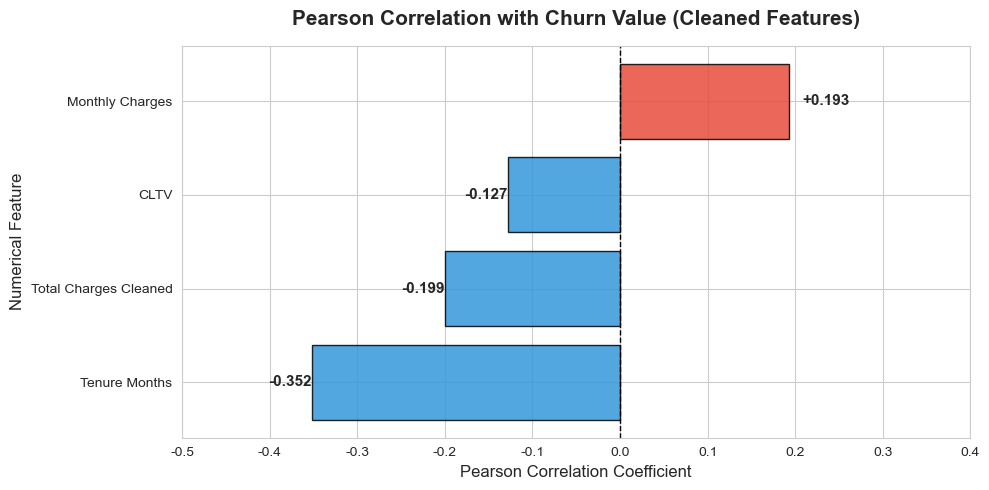

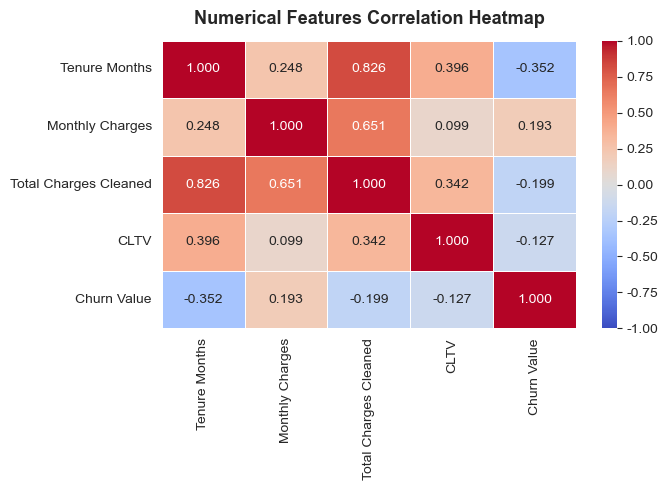

In [32]:
# ============================================================
# 2-1. 수치형 변수 - 타겟 상관관계 분석 (df 기준)
# ============================================================

df_num_analysis = df.copy()
df_num_analysis['Total Charges Cleaned'] = pd.to_numeric(df_num_analysis['Total Charges'].astype(str).str.strip(), errors='coerce')

# Churn Score가 제거되었으므로순수 순수 고객 행동 지표 4개만 분석
num_features = ['Tenure Months', 'Monthly Charges', 'Total Charges Cleaned', 'CLTV']
corr_target = df_num_analysis[num_features].corrwith(df_num_analysis['Churn Value']).sort_values(ascending=True)

plt.figure(figsize=(10, 5))
colors = ['#e74c3c' if val > 0 else '#3498db' for val in corr_target.values]
bars = plt.barh(corr_target.index, corr_target.values, color=colors, edgecolor='black', alpha=0.85)

plt.axvline(0, color='black', linewidth=1, linestyle='--')
plt.title('Pearson Correlation with Churn Value (Cleaned Features)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Pearson Correlation Coefficient', fontsize=12)
plt.ylabel('Numerical Feature', fontsize=12)
plt.xlim(-0.5, 0.4)

for bar in bars:
    width = bar.get_width()
    offset = 0.015 if width >= 0 else -0.05
    plt.text(width + offset, bar.get_y() + bar.get_height()/2, f'{width:+.3f}', 
             va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
sns.heatmap(df_num_analysis[num_features + ['Churn Value']].corr(), annot=True, fmt='.3f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Numerical Features Correlation Heatmap', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

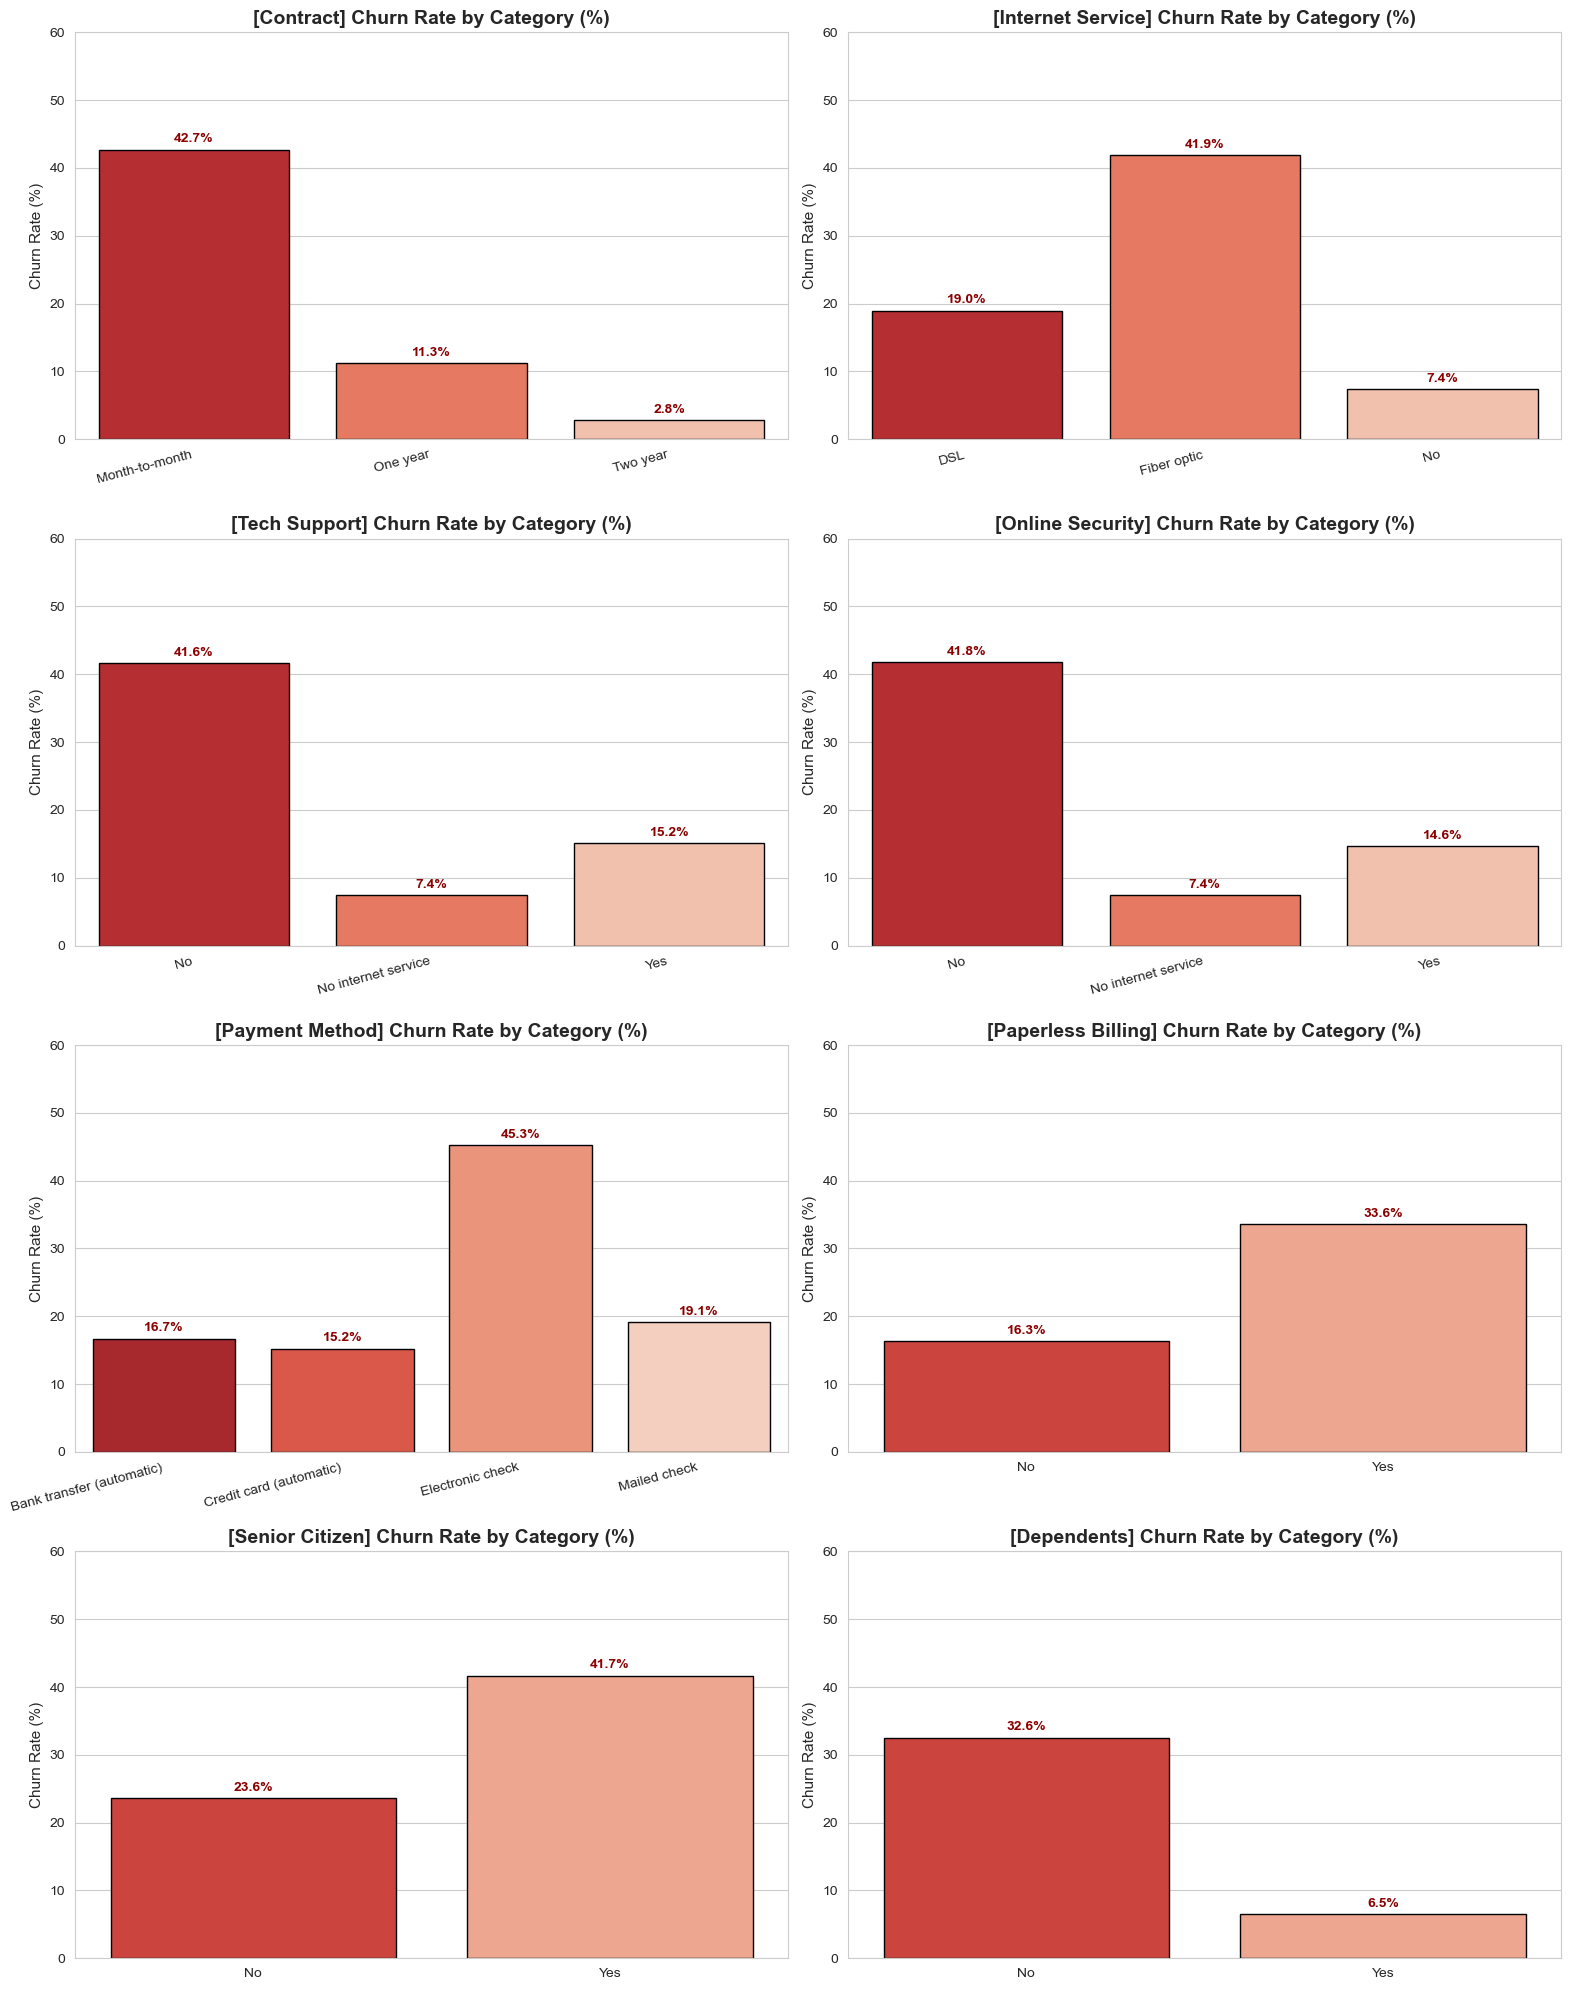

In [33]:
# ============================================================
# 2-2. 범주형 변수 - 범주별 이탈률 분석 (df 기준)
# ============================================================

cat_features = [
    'Contract', 'Internet Service', 'Tech Support', 'Online Security',
    'Payment Method', 'Paperless Billing', 'Senior Citizen', 'Dependents'
]

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    df_grouped = df.groupby(col)['Churn Value'].agg(['count', 'mean']).reset_index()
    df_grouped['churn_pct'] = df_grouped['mean'] * 100
    
    ax = axes[i]
    sns.barplot(data=df_grouped, x=col, y='churn_pct', ax=ax, palette='Reds_r', edgecolor='black')
    ax.set_title(f'[{col}] Churn Rate by Category (%)', fontsize=14, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Churn Rate (%)', fontsize=11)
    ax.set_ylim(0, 60)
    
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f'{height:.1f}%', (p.get_x() + p.get_width() / 2., height + 1.5),
                        ha='center', va='center', fontsize=10, fontweight='bold', color='darkred')
    
    if len(ax.get_xticklabels()) > 2:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')

plt.tight_layout()
plt.show()

## 3. 데이터 누수(Data Leakage) 피처 검증 및 최종 전처리 상태 확인

전처리 데이터셋(`df`)에서 `Churn Reason`, `Churn Label`, `Churn Score` 피처가 완전히 제거되어 **Data Leakage 위험이 100% 차단되었음**을 최종 검증합니다.

In [34]:
# ============================================================
# 3. Data Leakage 차단 검증 및 최종 Shape 출력
# ============================================================

leakage_cols = ['Churn Reason', 'Churn Label', 'Churn Score']
remaining_leakage = [c for c in leakage_cols if c in df.columns]

print('='*50)
print('🛡️ [Data Leakage 최종 검증 결과]')
if len(remaining_leakage) == 0:
    print('✅ 성공: Data Leakage 의심 피처 3개가 df에서 완전히 제거되었습니다.')
else:
    print(f'⚠️ 경고: 여전히 남아있는 피처: {remaining_leakage}')

print(f'📊 최종 분석 데이터셋 (df) Shape: {df.shape}')
print(f'📋 남은 컬럼 목록 ({len(df.columns)}개): {list(df.columns)}')
print('='*50)

🛡️ [Data Leakage 최종 검증 결과]
✅ 성공: Data Leakage 의심 피처 3개가 df에서 완전히 제거되었습니다.
📊 최종 분석 데이터셋 (df) Shape: (7043, 32)
📋 남은 컬럼 목록 (32개): ['CustomerID', 'Count', 'Country', 'State', 'City', 'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value', 'CLTV', 'Zip3', 'Area_Avg_Income', 'Area_Pop_Density']


## 4. 최종 분석 리포트 (전처리 후 피처 의사결정 요약)

--- 

### 🗑️ 이미 제거 완료된 데이터 누수/중복 피처 (총 3개)
- `Churn Label`: 타겟 변수 `Churn Value`와 1:1 완벽 중복 (제거 완료)
- `Churn Score`: IBM 내부 예측 모델 산출물 (Data Leakage, 제거 완료)
- `Churn Reason`: 이탈 후 기록된 73.5% 결측 사후 데이터 (Data Leakage, 제거 완료)

---

### 🟢 1. [유지 권장] 이탈 예측에 유의미한 패턴을 보이는 핵심 피처 (총 17개)
- **계약 및 거래 지표**: `Contract`, `Tenure Months`, `Monthly Charges`, `Total Charges`, `CLTV`
- **핵심 서비스 & 부가서비스**: `Internet Service`, `Tech Support`, `Online Security`, `Online Backup`, `Device Protection`, `Streaming TV`, `Streaming Movies`, `Phone Service`, `Multiple Lines`
- **고객 행동 & 인구통계**: `Payment Method`, `Paperless Billing`, `Dependents`, `Senior Citizen`, `Partner`

---

### 🟡 2. [추가 삭제 검토 요망] 모델링 전 삭제 고려 피처 (총 10개)
- **단일값 변수 (분산 0, 정보량 0%)**: `Count`, `Country`, `State` → **[삭제 권장]**
- **고유 식별자 (과적합 유발)**: `CustomerID` → **[삭제 권장]**
- **위치 좌표 및 세부 지역 (고가디널리티/노이즈)**: `City`, `Zip Code`, `Lat Long`, `Latitude`, `Longitude` → **[삭제 검토 (지역 그룹핑 전처리 미진행 시 삭제)]**
- **변별력 저하 변수**: `Gender` (Male 26.2% vs Female 26.9%로 차이가 0.7%p에 불과함) → **[삭제 검토]**